# Question 1 How do customers age and gender influence their spending?

In [6]:
# Load libraries and data
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df = pd.read_csv("customer_shopping_data.csv")
df = df[["customer_id", "age", "gender", "price"]].dropna()
df.head()

,customer_id,age,gender,price
0,C241288,28,Female,1500.40
1,C111565,21,Male,1800.51
2,C266599,20,Male,300.08
3,C988172,66,Female,3000.85
4,C189076,53,Female,60.60


In [3]:
# Function for age bins
def make_age_bins(age):
    bins = [0,20,30,40,50,60,70]
    labels = ["<=20","21-30","31-40","41-50","51-60","61-70"]
    return pd.cut(age, bins=bins, labels=labels, include_lowest=True)

In [4]:
# Group data for EDA
df["age_bin"] = make_age_bins(df["age"])
summary = df.groupby(["age_bin","gender"])["price"].mean().reset_index()
summary

/var/folders/l3/sxwp32g53kggckdrmjh015mm0000gn/T/ipykernel_48192/3712204424.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(["age_bin","gender"])["price"].mean().reset_index()


,age_bin,gender,price
0,<=20,Female,672.706756
1,<=20,Male,661.849883
2,21-30,Female,699.024482
3,21-30,Male,684.268032
4,31-40,Female,687.804740
5,31-40,Male,685.685200
6,41-50,Female,687.282348
7,41-50,Male,710.144030
8,51-60,Female,685.859592
9,51-60,Male,687.416210


<Figure size 600x400 with 0 Axes>

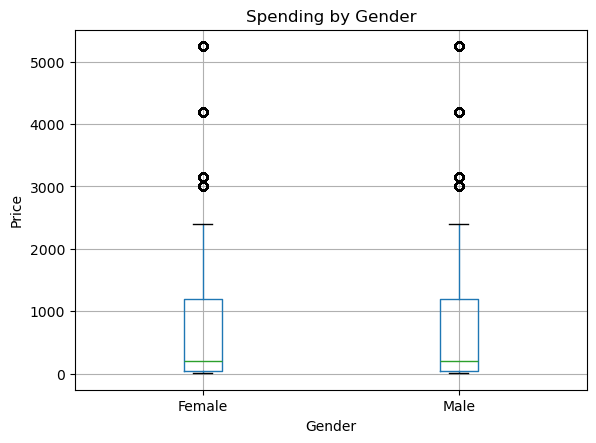

In [5]:
# Boxplot by gender
plt.figure(figsize=(6,4))
df.boxplot(column="price", by="gender")
plt.title("Spending by Gender")
plt.suptitle("")
plt.ylabel("Price")
plt.xlabel("Gender")
plt.show()

<Figure size 800x500 with 0 Axes>

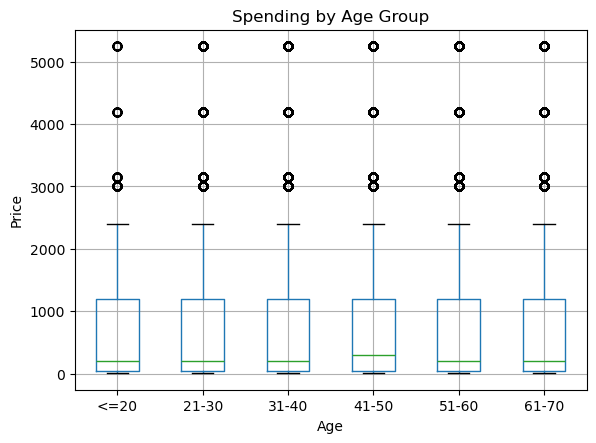

In [6]:
# Boxplot by age group
plt.figure(figsize=(8,5))
df.boxplot(column="price", by="age_bin")
plt.title("Spending by Age Group")
plt.suptitle("")
plt.ylabel("Price")
plt.xlabel("Age")
plt.show()

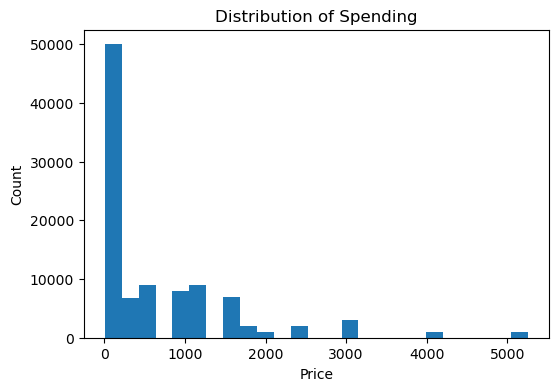

In [7]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(df["price"], bins=25)
plt.title("Distribution of Spending")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [8]:
cust = df.groupby("customer_id").agg(
    total_spending=("price","sum"),
    age=("age","first"),
    gender=("gender","first")
).reset_index()

cust["gender_num"] = cust["gender"].map({"Female":0,"Male":1}).fillna(0)

thr = cust["total_spending"].median()
cust["high_spender"] = (cust["total_spending"] >= thr).astype(int)

X = cust[["age","gender_num"]]
y = cust["high_spender"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [9]:
# Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]

print("LR Accuracy:", round(accuracy_score(y_test, y_pred_lr),3))
print("LR AUC:", round(roc_auc_score(y_test, y_prob_lr),3))

LR Accuracy: 0.527
LR AUC: 0.501


In [10]:
# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
y_prob_knn = knn.predict_proba(X_test_s)[:,1]

print("KNN Accuracy:", round(accuracy_score(y_test, y_pred_knn),3))
print("KNN AUC:", round(roc_auc_score(y_test, y_prob_knn),3))

KNN Accuracy: 0.512
KNN AUC: 0.499


# Question 2 - Are there specific months or seasons where certain categories are more popular or expensive?

## First Step - 
*Loading Data* 

*Turning the date in the data file to date object*

*Get the month from the date* 

*Get the total for the purchases* 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('customer_shopping_data.csv')
# Turn date into proper date object instead of text 
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
# Gets the month from the date
df['month'] = df['invoice_date'].dt.month
# Gets the total 
df['total_amount'] = df['quantity'] * df['price']

## Step 2 - 
*Making a chart to show monthly sales by category* 

This is to see if there are any important changes in sales throughout the year 

<Figure size 1200x600 with 0 Axes>

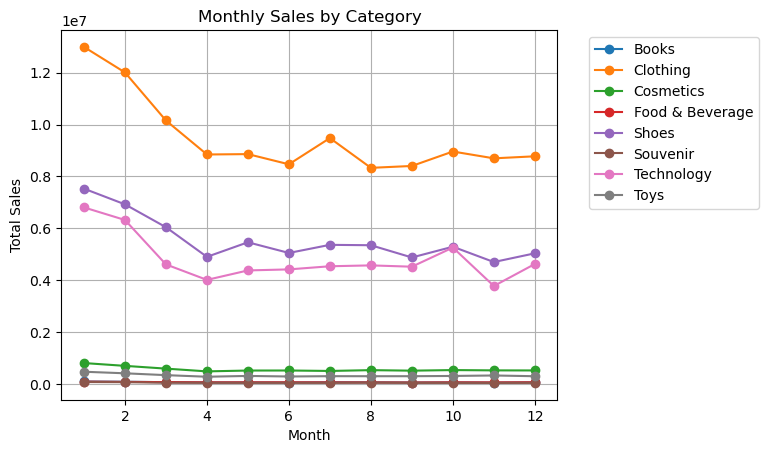

In [11]:
# Making a chart of monthy sales by category
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby(['month', 'category'])['total_amount'].sum().unstack()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales by Category')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.show()

## Results 

From the chart it seems that our top sales categories are clothing, shoes, and technology. While clothing dominates by a large margin in the sales. The data goes from January to December, but for most of the categories the sales don't change much throughout the year. At the beginning of the year the sales are dropping for clothing, shoes, and technology. I think this is happening because the holiday season just passed. I will say for the top three categories, there might be season influence with clothing sales increase during Christmas season and the summer months with the spike. While Technology and shoes seems to happen only during Christmas from the downward slope in January.

## Step 3 
Building a Linear Regression model and KNN.

In [12]:
#Building the two models Linear Regression and KNN  
model_data = df.groupby(['month', 'category']).agg({
    'total_amount': 'sum',
    'quantity': 'sum',
    'price': 'mean'
}).reset_index()

# Encode categories
le = LabelEncoder()
model_data['category_encoded'] = le.fit_transform(model_data['category'])

X = model_data[['month', 'category_encoded']]
y = model_data['total_amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# KNN 
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print("Model Performance (MAE):")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"KNN MAE: {mean_absolute_error(y_test, knn_pred):.2f}")

Model Performance (MAE):
Linear Regression MAE: 2968628.16
KNN MAE: 3804385.88


## Results 
The performance of the two model are not performing well, with linear regression doing better. This could be because the model is too simple. This shows that this model is underfitting and a way to fix this is to include more features to predict from like holidays and promotions could make the predictions more accurate. Those features are not available in the dataset.  

## Step 4 - visualize the models 

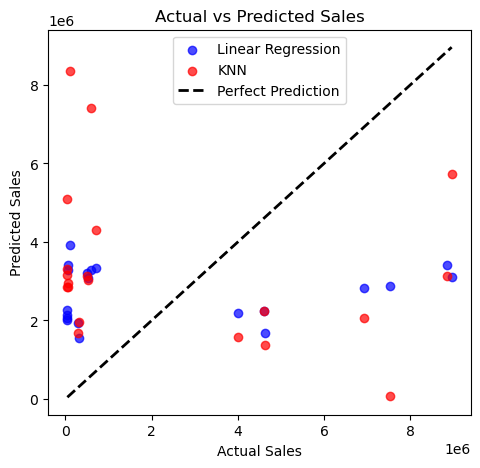

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.7, label='Linear Regression', color='blue')
plt.scatter(y_test, knn_pred, alpha=0.7, label='KNN', color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()

## Summary - 
Linear regression is the better model between the two, but both model are showing signs of underfitting. The categories like clothing, shoes, and technology seems like they have better sales during December around Christmas. Clothing has a spike during the summer.   


# Question 3
### Which product categories generate the highest average spending per transaction?
**Columns for analysis**
* `category`: represents product categoried such as Shoes, Technology, etc.
* `price`: represents spending per transaction. 
First, we are going to define a function called `plot_mean_spending_by_category`. The purpose of this function is to help us identify which product categories generate the highest average spending per transaction. To do this, the function will first group the dataset by the `category` column, which represents different types of products. For each category, it will calculate the mean (average) value of the `price` column, which tells us how much, on average, customers spend in each category per transaction. After calculating these averages, the function will sort the categories from highest to lowest average spending, making it easy to see which categories stand out.

The function will then create a bar chart to visually display these results. In this chart, each bar represents a product category, and the height of the bar shows the average spending for that category. This visualization makes it much easier to compare categories at a glance than looking at raw numbers in a table. By using this function, we expect to directly answer our main question: which product categories generate the highest average spending per transaction? The categories with the tallest bars in the chart will be the ones that contribute the most revenue per transaction, helping us focus on the most valuable segments in the dataset.

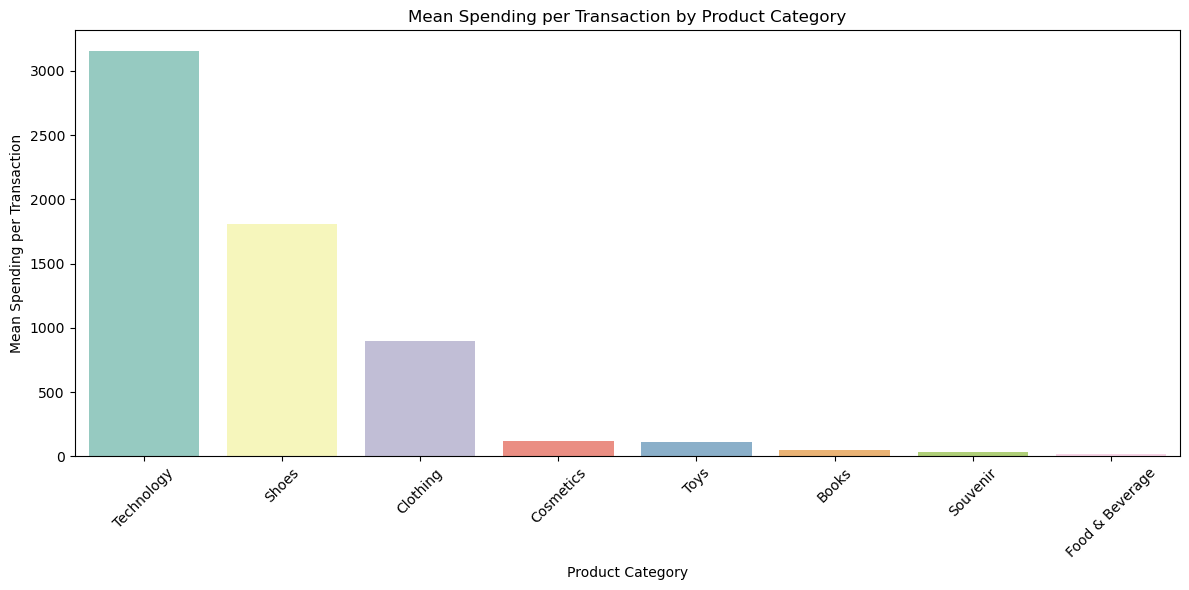

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_shopping_data.csv')
mean_spend = df.groupby('category')['price'].mean().sort_values(ascending=False).reset_index()
mean_spend.columns = ['category', 'mean_spend']

def plot_mean_spending_by_category(df):
    plt.figure(figsize=(12,6))
    sns.barplot(data=mean_spend, x='category', y='mean_spend', hue='category', palette='Set3', legend=False)
    plt.ylabel('Mean Spending per Transaction')
    plt.xlabel('Product Category')
    plt.title('Mean Spending per Transaction by Product Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return mean_spend

mean_spending = plot_mean_spending_by_category(df)

The bar chart above illustrates the average spending per transaction by product category. From the visualization, it is clear that the Technology category stands out as the top performer, recording the highest mean spending per transaction among all categories. Shoes and Clothing follow, but with noticeably lower averages than Technology.

On the other hand, categories such as Cosmetics, Toys, Books, Souvenir, and especially Food & Beverage display significantly lower average spending per transaction. This visual analysis answers our question directly: Technology products generate the highest average transaction value, followed by Shoes and Clothing.

By presenting each category with a different color, the chart makes these differences easy to distinguish at a glance. This insight is crucial for businesses or analysts looking to focus marketing efforts or strategize around categories that drive the most revenue per transaction.

Next, we are going to define a function called `plot_distribution_by_category`. The aim of this function is to help us understand how spending behavior varies within each product category, not just at the average level. While our bar chart showed which categories had higher average transaction amounts, it doesn’t reveal whether most transactions are close to that average or if spending is highly variable within a category.

In the `plot_distribution_by_category` function, we will visualize the distribution of spending amounts for each product category by using kernel density estimate (KDE) plots. For each category, we’ll display a smooth curve that shows how transaction amounts are spread; whether they cluster tightly around a single value, have a long tail of high-spending outliers, or are broadly distributed. By plotting all categories on the same axes, using different colors for each curve, we will make it easy to compare their shapes and identify differences in consumer behavior.

This visualization is important for answering questions like: "Do some categories attract a few very high spenders, or is spending consistent across transactions?" With this function, we expect to see not only which categories are generally profitable on average, but also how much variation or spread exists in spending patterns, which can be key for strategic planning and understanding market segments.

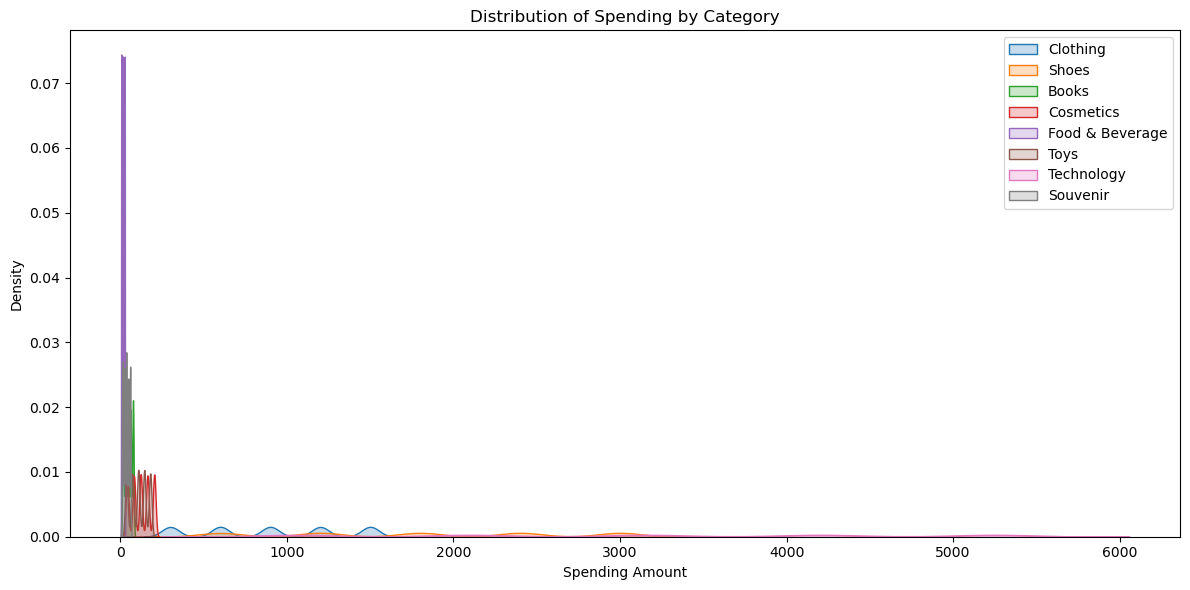

In [18]:
def plot_distribution_by_category(df):
    plt.figure(figsize=(12,6))
    for cat in df['category'].unique():
        sns.kdeplot(df[df['category']==cat]['price'], label=cat, fill=True)
    plt.xlabel('Spending Amount')
    plt.title('Distribution of Spending by Category')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_distribution_by_category(df)

The distribution plot above reveals how transaction amounts are spread within each product category. Most categories, such as Food & Beverage, Books, Cosmetics, Toys, and Souvenir, show a high density of transactions at low spending amounts which indicate that the majority of purchases in these segments are for relatively small sums. In contrast, categories like Clothing, Shoes, and especially Technology have a much broader distribution, with spending amounts extending much further along the x-axis. This means that while most purchases in lower-spending categories are small, shopping for Technology, Shoes, or Clothing can involve far higher transaction values.

From this visualization, we can see that the Technology category not only leads in terms of highest average spending (as the bar chart showed earlier) but also exhibits a wider range of spending, including some exceptionally large transactions. This spread explains why Technology maintains such a high average: it captures both everyday sales and high-value purchases. Meanwhile, the other categories tend to cluster tightly around lower transaction amounts, with little high-end spending. This helps us understand not just which categories are the top revenue drivers overall, but also how customer behavior varies by product type, highlighting the role of big-ticket purchases in certain categories.

In [19]:
print('Top Categories by Mean Spend:')
print(mean_spending.head(5))

Top Categories by Mean Spend:
     category   mean_spend
0  Technology  3156.935548
1       Shoes  1807.388568
2    Clothing   901.084021
3   Cosmetics   122.448626
4        Toys   107.733185


Combining the insights from both the bar chart, the distribution plot, and the summary data, we can clearly see that Technology is the product category with the highest average spending per transaction, around 3,157 per transaction. Shoes and Clothing are the next highest, but with averages that are significantly lower than Technology, at about 1,807 and 901, respectively. In contrast, other categories such as Cosmetics and Toys have much lower average spending per transaction, well under 150.

The distribution plots add further detail: they show that in Technology, Shoes, and Clothing, not only are averages higher, but transaction amounts are also more variable, with many high-value purchases, while categories like Cosmetics, Toys, and others are clustered tightly around low spending values.

**Key takeaway**: If the goal is to maximize average transaction revenue, focusing on Technology, Shoes, and Clothing will have the greatest impact. These categories invite both higher and more variable spending, likely reflecting bigger-ticket items compared to the smaller, more common purchases in Cosmetics, Toys, and similar categories. This information is valuable for marketing strategies, inventory prioritization, and understanding shopper behavior across categories.

# Question 4: Which payment methods and shopping malls are most associated with high-spending customers?

I used `payment_method`, `shopping_mall`, `price` to find where high spending happens.

1) Create a high/low spending label using the median of `price`.  
2) EDA tables (mean/median) by payment method and by mall.  
3) Visuals: countplots + heatmaps.  
4) Simple models (linear SVM vs Decision Tree) using just those two categorical features.

## 0. Load data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "customer_shopping_data.csv"

df = pd.read_csv(DATA_PATH, usecols=["payment_method","shopping_mall","price"]).dropna()
df = df[df["price"] > 0].reset_index(drop=True)
df.head()

,price,payment_method,shopping_mall
0,1500.40,Credit Card,Kanyon
1,1800.51,Debit Card,Forum Istanbul
2,300.08,Cash,Metrocity
3,3000.85,Credit Card,Metropol AVM
4,60.60,Cash,Kanyon


## 1. make high/low spending label (1 = high)

**High/low label.** I use the **median price** as the cutoff:  
- `price >= median` → label 1 (high spender)  
- otherwise 0 (low)

Why median? It keeps the classes roughly balanced, which is helpful for AUC and accuracy.

In [22]:
def make_high_label(prices):
    threshold = prices.median()
    return (prices >= threshold).astype(int), float(threshold)

df["high_spender"], cutoff = make_high_label(df["price"])
cutoff

203.3

## 2. EDA (groupby mean/median)

**Payment method (mean price):**
- Cash ≈ **690.82**
- Credit Card ≈ **688.54**
- Debit Card ≈ **687.03**
→ The three are **very close**; Cash is just slightly higher on average.

**Shopping mall (mean price):**
1) **Emaar Square Mall ≈ 704.72**
2) **Viaport Outlet ≈ 694.75**
3) **Mall of Istanbul ≈ 694.57**
4) Kanyon ≈ 691.66 5) Zorlu Center ≈ 691.56  
→ **Emaar Square Mall** stands out with the highest average ticket. The gap from top to bottom mall is ~**30** (704.7 vs 674.4).

In [24]:
pm_stats = df.groupby("payment_method")["price"].agg(["count","mean","median"]).sort_values("mean", ascending=False)
mall_stats = df.groupby("shopping_mall")["price"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

pm_stats, mall_stats

(                count        mean  median
 payment_method                           
 Cash            44447  690.823475   203.3
 Credit Card     34931  688.542467   203.3
 Debit Card      20079  687.029135   203.3,
                    count        mean  median
 shopping_mall                               
 Emaar Square Mall   4811  704.720081  300.08
 Viaport Outlet      4914  694.753655  300.08
 Mall of Istanbul   19943  694.566395  203.30
 Kanyon             19823  691.658944  203.30
 Zorlu Center        5075  691.556457  203.30
 Cevahir AVM         4991  687.972719  203.30
 Istinye Park        9781  686.747525  203.30
 Metrocity          15011  682.831262  203.30
 Metropol AVM       10161  682.806120  203.30
 Forum Istanbul      4947  674.363012  203.30)

## 3. Visualizations

### 3.1 Countplots

**Countplots (high vs low).**
- By payment method: the mix of high vs low looks similar across Cash / Credit / Debit (expected with a median split).
- By mall: big malls like **Kanyon, Mall of Istanbul, Emaar Square Mall** show the largest bars, and their **high-spender bars are slightly taller**.

These plots show **how many** high vs low customers we have in each category.

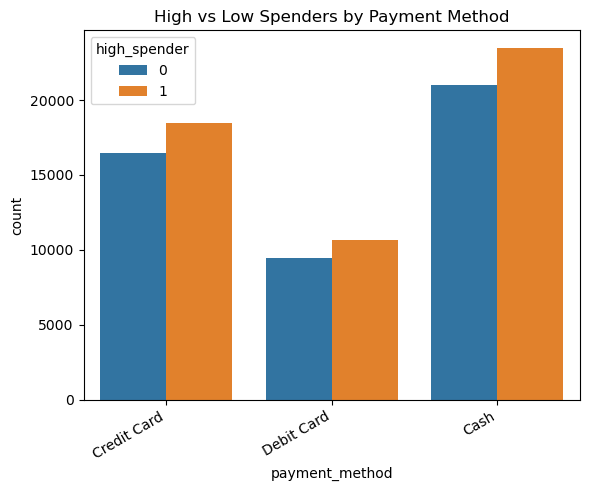

In [28]:
sns.countplot(data=df, x="payment_method", hue="high_spender")
plt.title("High vs Low Spenders by Payment Method")
plt.xticks(rotation=30, ha="right")
plt.show()

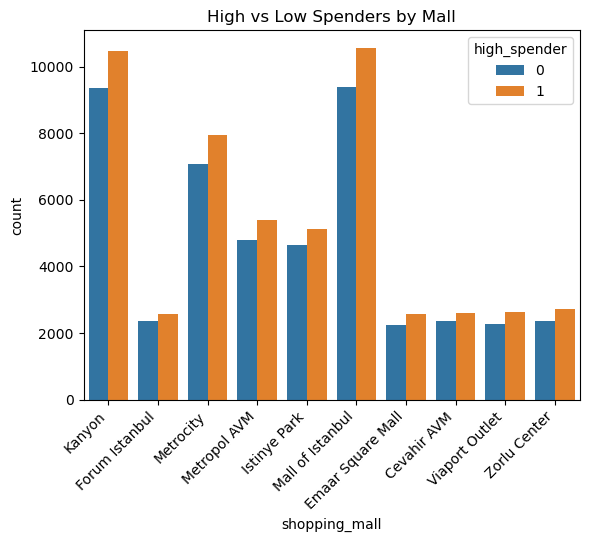

In [29]:
sns.countplot(data=df, x="shopping_mall", hue="high_spender")
plt.title("High vs Low Spenders by Mall")
plt.xticks(rotation=45, ha="right")
plt.show()

### 3.2 Heatmaps (mean price & high‑spender rate)

1) **Mean price**: brightest cells = higher average ticket.
   - **Cash @ Emaar Square Mall ≈ 731** (brightest)
   - **Debit @ Cevahir AVM ≈ 724**
   - **Credit @ Zorlu Center ≈ 721**

2) **High-spender rate**: brightest cells = higher share of label=1.
   - Most cells are around **0.52–0.54**
   - **Cash @ Emaar Square Mall ≈ 0.55** is the top rate

**Visual takeaway.** **Emaar Square Mall** pops on both metrics. A few payment×mall pairs (Cash@Emaar, Debit@Cevahir, Credit@Zorlu) also stand out, but differences are **modest** overall.

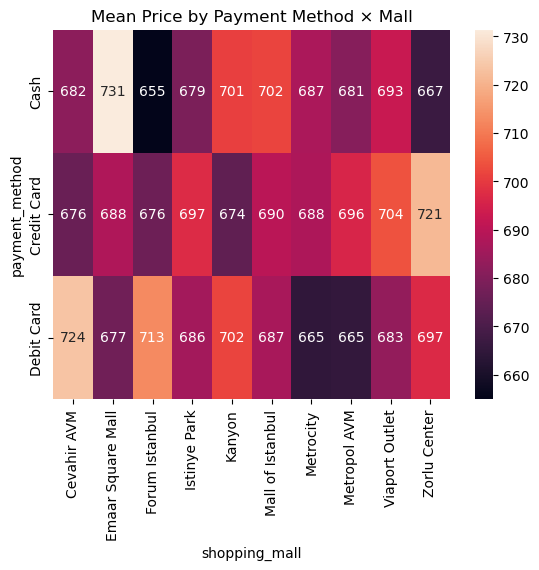

In [30]:
# Mean price by (payment × mall)
mean_price = df.pivot_table(index="payment_method", columns="shopping_mall", values="price", aggfunc="mean")
sns.heatmap(mean_price, annot=True, fmt=".0f")
plt.title("Mean Price by Payment Method × Mall")
plt.show()

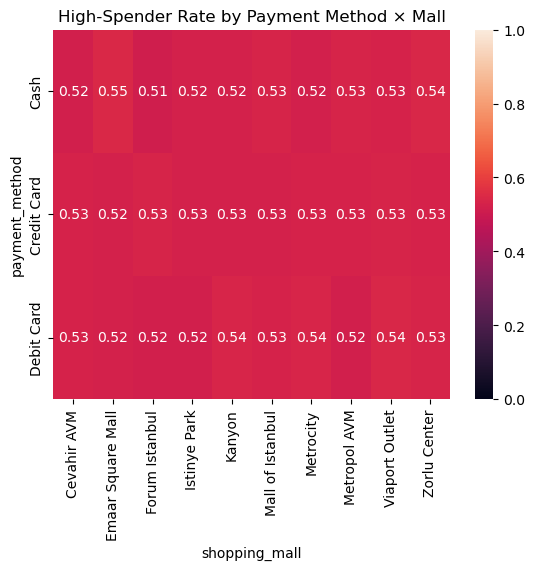

In [31]:
# High‑spender rate by (payment × mall)
rate_high = df.pivot_table(index="payment_method", columns="shopping_mall", values="high_spender", aggfunc="mean")
sns.heatmap(rate_high, annot=True, fmt=".2f", vmin=0, vmax=1)
plt.title("High‑Spender Rate by Payment Method × Mall")
plt.show()

## 4. Predictive Models (SVM vs Decision Tree)

**Baseline models.** Only `payment_method` and `shopping_mall` (one-hot).
- Split: 80/20, `random_state=42`, `stratify=y`
- Models: **Linear SVM** (fast) and **Decision Tree**
- Metrics: **AUC** (main) and **Accuracy** (secondary)

**Results (test set).**
- Linear SVM → **Accuracy ≈ 0.5286**, **AUC ≈ 0.4984**
- Decision Tree → **Accuracy ≈ 0.5286**, **AUC ≈ 0.4976**

**Reading the plots.**
- **ROC curves** are near the diagonal → AUC ~0.5, so the two features alone don’t separate high vs low.
- **Confusion matrices** show the models mostly predict the positive class, which explains the ~0.53 accuracy (similar to the positive rate).

**Interpretation.** Payment method and mall are helpful for **segmentation** (where bigger receipts happen), but **by themselves** they are **not strong predictors** of who will be high-spending.

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier


X = pd.get_dummies(df[["payment_method", "shopping_mall"]], drop_first=False)
y = df["high_spender"] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


svm  = LinearSVC(random_state=42, dual='auto')
tree = DecisionTreeClassifier(random_state=42)

svm.fit(X_train, y_train)
tree.fit(X_train, y_train)

svm_acc = accuracy_score(y_test, svm.predict(X_test))
tree_acc = accuracy_score(y_test, tree.predict(X_test))

svm_auc = roc_auc_score(y_test, svm.decision_function(X_test))
tree_auc = roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])

print("SVM  -> Acc:", round(svm_acc, 4), " AUC:", round(svm_auc, 4))
print("Tree -> Acc:", round(tree_acc, 4), " AUC:", round(tree_auc, 4))

SVM  -> Acc: 0.5286  AUC: 0.4984
Tree -> Acc: 0.5286  AUC: 0.4976


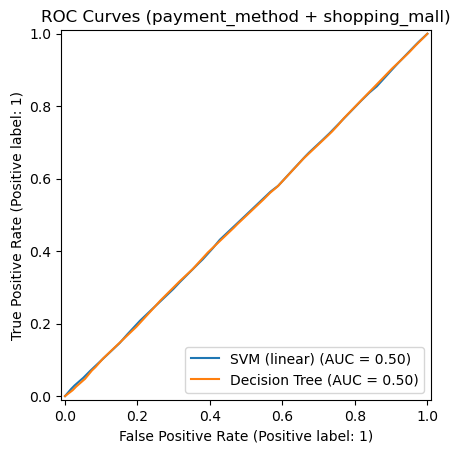

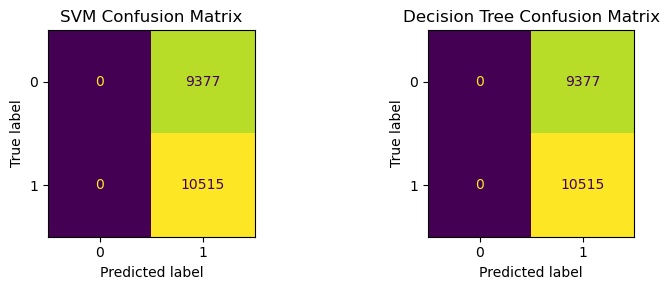

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# 1) ROC curves
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(
    svm, X_test, y_test, name="SVM (linear)",
    ax=ax, response_method="decision_function" 
)
RocCurveDisplay.from_estimator(
    tree, X_test, y_test, name="Decision Tree", ax=ax
)
ax.set_title("ROC Curves (payment_method + shopping_mall)")
plt.show()

# 2) Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
ConfusionMatrixDisplay.from_estimator(svm,  X_test, y_test, ax=axes[0], colorbar=False)
axes[0].set_title("SVM Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree Confusion Matrix")
plt.tight_layout(); plt.show()

## Conclusion
- **Payment methods:** averages are very close; **Cash** is slightly higher than cards.
- **Shopping malls:** **Emaar Square Mall** has the **highest mean price (~704.7)**; **Viaport Outlet** and **Mall of Istanbul** follow.
- **Strong pairs (by visuals):** **Cash @ Emaar Square Mall (~731, rate ~0.55)** is the clearest hotspot; **Debit @ Cevahir AVM (~724)** and **Credit @ Zorlu Center (~721)** also stand out.